In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from imblearn.under_sampling import RandomUnderSampler

In [4]:
data = pd.read_csv("../data/creditcard.csv")
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)
scaler = RobustScaler()
minmax = MinMaxScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_val['Amount'] = scaler.transform(X_val[['Amount']])
X_train['Time'] = minmax.fit_transform(X_train[['Time']])
X_val['Time'] = minmax.transform(X_val[['Time']])

# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2, stratify=y_train)

# Ресэмплинг

In [5]:
rus = RandomUnderSampler(random_state=42)
X_train_r, y_train_r = rus.fit_resample(X_train, y_train)

In [6]:
y_train_r.value_counts()

Class
0    344
1    344
Name: count, dtype: int64

In [7]:
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_train_r, y_train_r, test_size=.3, random_state=42, stratify=y_train_r)

# Дерево решений

### Обучение дерева на уменьшненной выборке с одинаковым соотношением fraud и non fraud

              precision    recall  f1-score   support

   non-fraud       0.96      0.88      0.92       104
       fraud       0.89      0.96      0.93       103

    accuracy                           0.92       207
   macro avg       0.93      0.92      0.92       207
weighted avg       0.93      0.92      0.92       207



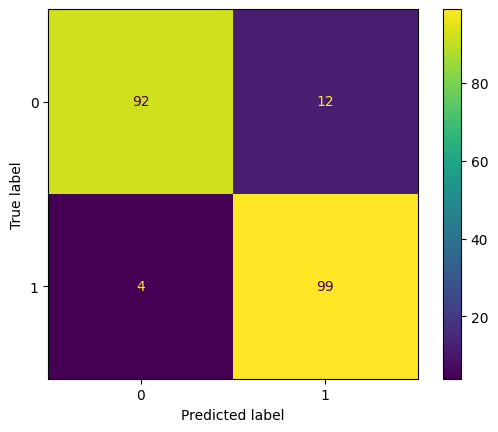

In [8]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train_r, y_train_r)
print(classification_report(y_val_r, model.predict(X_val_r), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val_r, model.predict(X_val_r))).plot()

### Проверка дерева решения на валидационной выборке с оригиальным распределением классов

              precision    recall  f1-score   support

   non-fraud       1.00      0.92      0.96     85295
       fraud       0.02      0.91      0.04       148

    accuracy                           0.92     85443
   macro avg       0.51      0.91      0.50     85443
weighted avg       1.00      0.92      0.96     85443



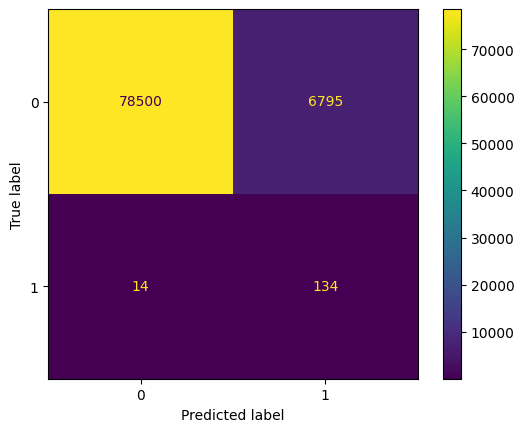

In [9]:
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

### Здесь андресэмлпинг сыграл злую шутку. Хотя благодаря нему модель смогла научиться отделять fraud от non-fraud, это привело к тому, что модель немного переобучилась на классе fraud, и теперь предсказывает non-fraud операции как мошеннические. С точки зрения бизнеса это не так страшно, как пропустить fraud операцию, но 2753 клиента, получившие блокировку транзакций точно не скажут за это "спасибо"

# Дерево решений с взешененными классами (cost-aware learning)

              precision    recall  f1-score   support

   non-fraud       0.96      0.87      0.91       104
       fraud       0.88      0.96      0.92       103

    accuracy                           0.91       207
   macro avg       0.92      0.91      0.91       207
weighted avg       0.92      0.91      0.91       207



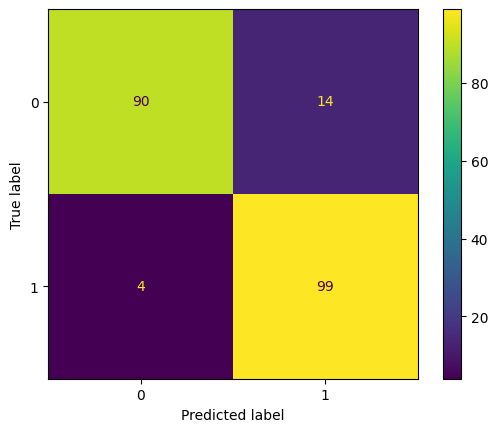

In [10]:
model = DecisionTreeClassifier(max_depth=4, class_weight={0: 1, 1: 2})
model.fit(X_train_r, y_train_r)
print(classification_report(y_val_r, model.predict(X_val_r), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val_r, model.predict(X_val_r))).plot()

### Проверка

              precision    recall  f1-score   support

   non-fraud       1.00      0.88      0.94     85295
       fraud       0.01      0.88      0.03       148

    accuracy                           0.88     85443
   macro avg       0.51      0.88      0.48     85443
weighted avg       1.00      0.88      0.94     85443



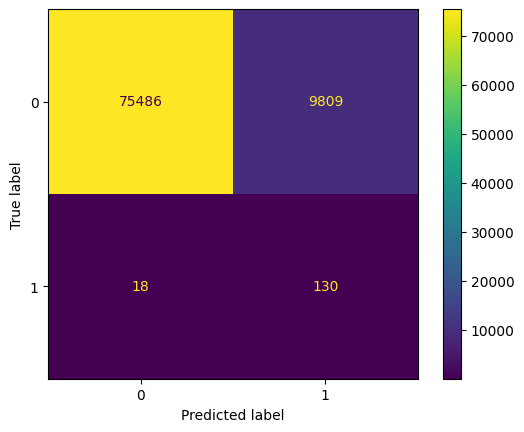

In [11]:
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

### Вердикт: взвешивание классов сделало модель излишне "зашуганной", она боится ошибиться и из-за этого ошибается еще сильнее, делая больше false positive предсказаний

### Также наблюдается огромная разница метрик на оригинальных данных и на уменьшенных. Происходит это ввиду того, что при текущем подходе к андерсэмплинге случайным образом удалются мажорные классы, пока соотношение fraud к non-fraud не станет 50 на 50. Во время такого процесса теряется очень много данных. Поэтому стоит подохдить к андерсэмплингу менее агрессивно.

# Обучение дерева на уменьшенной выборке с более высоким соотношение fraud к non-fraud

In [42]:
from sklearn.utils import resample


X_train_res = pd.concat([X_train, y_train], axis=1)

fraud = X_train_res.loc[X_train_res.Class == 1]
non_fraud = X_train_res.loc[X_train_res.Class == 0]

n_fraud = len(fraud)

n_non_fraud = n_fraud * 10

non_fraud = resample(
    non_fraud,
    n_samples=n_non_fraud,
    replace=False,
    random_state=42
)

resampled_data = pd.concat([fraud, non_fraud])
resampled_data.Class.value_counts()

Class
0    3440
1     344
Name: count, dtype: int64

              precision    recall  f1-score   support

   non-fraud       0.98      1.00      0.99      1033
       fraud       0.96      0.84      0.90       103

    accuracy                           0.98      1136
   macro avg       0.97      0.92      0.94      1136
weighted avg       0.98      0.98      0.98      1136



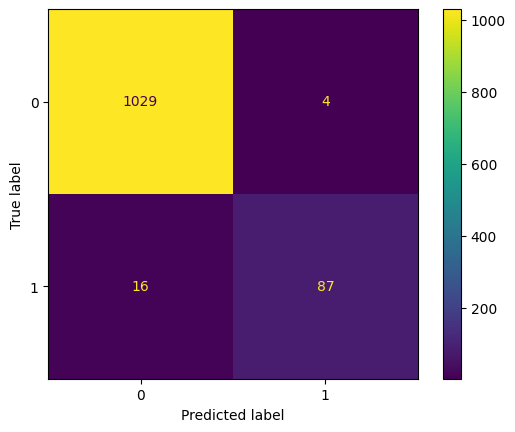

In [43]:
X_r = resampled_data.drop(['Class'], axis=1)
y_r = resampled_data['Class']
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_r, y_r, test_size=.3, stratify=y_r, random_state=42)

model = DecisionTreeClassifier(max_depth=4, class_weight={0:1,1:1})
model.fit(X_train_r, y_train_r)
print(classification_report(y_val_r, model.predict(X_val_r), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val_r, model.predict(X_val_r))).plot()

### Проверка

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     85295
       fraud       0.39      0.80      0.53       148

    accuracy                           1.00     85443
   macro avg       0.70      0.90      0.76     85443
weighted avg       1.00      1.00      1.00     85443



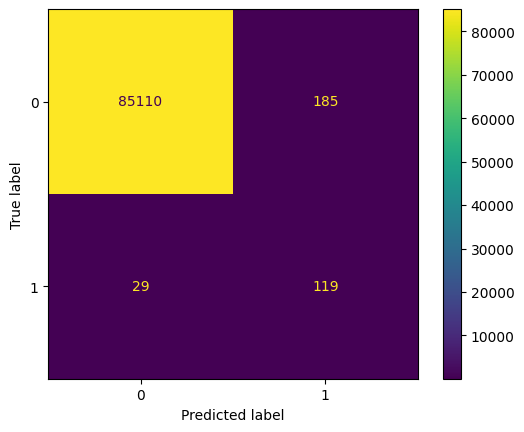

In [44]:
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

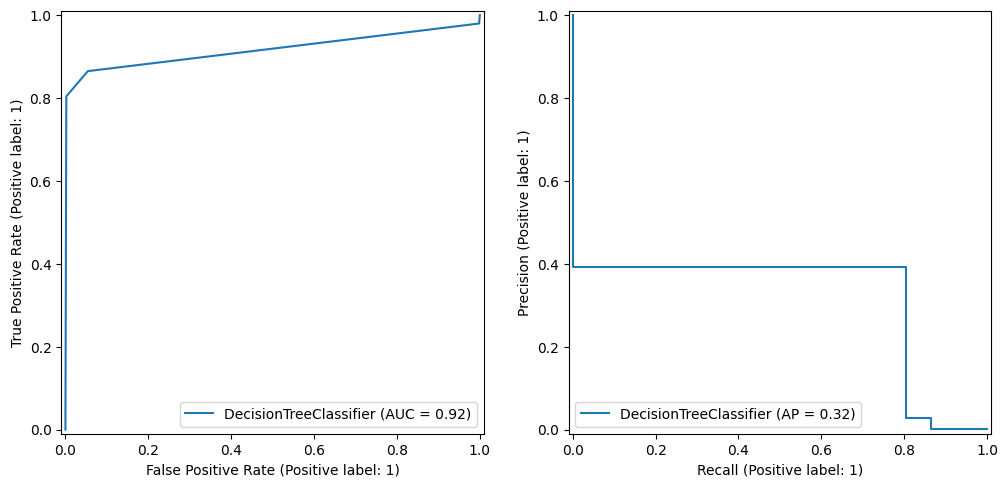

In [45]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0])
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[1])

### Обучение дерева с тщательно подобранными весами классов

In [34]:
n = len(y_train)
pos_weight = (1/(y_train == 1).sum()) * n/2
neg_weight = (1/(y_train == 0).sum()) * n/2
print(
    """
    вес негативного класса: {a}
    вес позитивного класса: {b}
    """.format(a=neg_weight, b=pos_weight)
)


    вес негативного класса: 0.5008642347502764
    вес позитивного класса: 289.7732558139535
    


              precision    recall  f1-score   support

   non-fraud       1.00      0.95      0.97     85295
       fraud       0.03      0.89      0.06       148

    accuracy                           0.95     85443
   macro avg       0.51      0.92      0.51     85443
weighted avg       1.00      0.95      0.97     85443



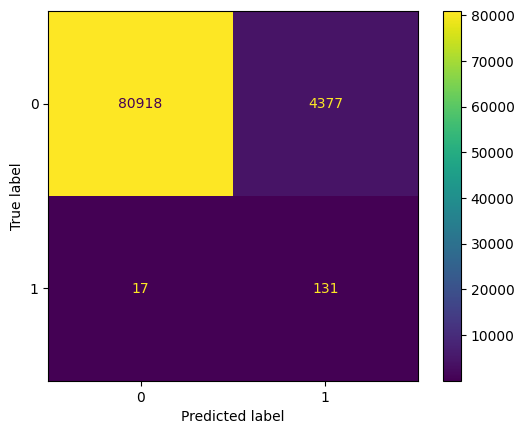

In [35]:



model = DecisionTreeClassifier(max_depth=4, class_weight={0:neg_weight,1:pos_weight})
model.fit(X_train, y_train)
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

### Вердикт: 
- Изменение соотношения fraud к non-fraud с 50:50 на 1:10 реально помогло. Такое соотношение помогает модели быстрее понять, что классы имеют разную частоту встречаемости, и модель лучше подстраивается под такие данные. Получилось добиться малого количества как false negative, так и false positive. Однако 29 false negative все таки не мало, с точки зрения бизнеса.
- Обучение на тренировочном наборе с оригинальным распределением классов и взвешиванием классов в соотвествии с их распределением действительно работает, получилось достичь увеличенного по сравнению с предыдущим подходом количества true positive и значительно уменьшенного количество false negative, вот только этого уменьшения удалось достичь пожертвовав метрикой precision для класса fraud. Четыре тысячи законных транзакций, классифицированных как незаконные, это не мало. Клиенты будут недовольны.


Оба подхода имеют свои плюсы и минусы. В дальнейшем я буду сравнивать их на более мощных моделях, стараясь найти оптимальное соотношение precision-recall

# Случайный лес (и сравнение двух подходов)

In [ ]:
from sklearn.ensemble
